# Mundial26 — Phase 4: Monte Carlo Tournament Simulator (Live Nowcast)

The payoff. We take the Dixon–Coles strengths, refit them on **all matches played through
today** (including the World Cup games already completed), read the **current group
standings** from those results, then simulate the **remaining** matches — group games plus
the entire knockout bracket — thousands of times.

The output is the headline of the whole project: *"Team X has a Y% chance of winning the
2026 World Cup,"* updated for what's actually happened so far.

### Why this is a live nowcast, not a pre-tournament guess
The dataset lists all 72 group fixtures. The ones already played have real scores; the rest
are blank. We fit on what's played, lock in the real standings, and only roll dice on what's
left. Re-download the dataset tomorrow and rerun — the forecast moves with the tournament.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import gammaln
from scipy.optimize import minimize

rng = np.random.default_rng(42)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load data; split played vs remaining

A match counts as **played** if it has a score. We fit the model on every played match in
history. We separately pull the 2026 World Cup fixtures and split them into completed games
(real results, locked in) and remaining games (to be simulated).

In [2]:
df = pd.read_csv("../data/raw/results.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)

played = df[df["home_score"].notna() & df["away_score"].notna()].copy()
played["home_score"] = played["home_score"].astype(int)
played["away_score"] = played["away_score"].astype(int)

wc = df[(df["tournament"] == "FIFA World Cup") & (df["date"] >= "2026-06-01")].copy()
wc_played    = wc[wc["home_score"].notna()].copy()
wc_remaining = wc[wc["home_score"].isna()].copy()

print(f"Total played matches (for fitting): {len(played)}")
print(f"2026 WC games played:    {len(wc_played)}")
print(f"2026 WC games remaining: {len(wc_remaining)}")
print(f"Latest played date: {played['date'].max().date()}")

Total played matches (for fitting): 49425
2026 WC games played:    20
2026 WC games remaining: 52
Latest played date: 2026-06-16


## 3. The 12 groups
Using the official 2026 draw, with team names matched to the dataset's spelling.

In [3]:
GROUPS = {
    "A": ["Mexico", "South Korea", "South Africa", "Czech Republic"],
    "B": ["Canada", "Switzerland", "Qatar", "Bosnia and Herzegovina"],
    "C": ["Brazil", "Morocco", "Scotland", "Haiti"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Ecuador", "Ivory Coast", "Curaçao"],
    "F": ["Netherlands", "Japan", "Tunisia", "Sweden"],
    "G": ["Belgium", "Iran", "Egypt", "New Zealand"],
    "H": ["Spain", "Uruguay", "Saudi Arabia", "Cape Verde"],
    "I": ["France", "Senegal", "Norway", "Iraq"],
    "J": ["Argentina", "Austria", "Algeria", "Jordan"],
    "K": ["Portugal", "Colombia", "Uzbekistan", "DR Congo"],
    "L": ["England", "Croatia", "Panama", "Ghana"],
}
wc_teams = [t for g in GROUPS.values() for t in g]
team_group = {t: g for g, ts in GROUPS.items() for t in ts}
assert len(wc_teams) == 48
print("48 teams loaded across 12 groups.")

48 teams loaded across 12 groups.


## 4. Refit Dixon–Coles on current data

Same model as Phase 3, but fit on matches from 2018 onward (time-decayed toward today) so the
strengths reflect *current* form — not 2017. This takes a couple of minutes.

In [4]:
fit_df = played[played["date"] >= "2018-01-01"].copy()
counts = pd.concat([fit_df["home_team"], fit_df["away_team"]]).value_counts()
keep = set(counts[counts >= 15].index) | set(wc_teams)   # ensure all WC teams included
fit_df = fit_df[fit_df["home_team"].isin(keep) & fit_df["away_team"].isin(keep)].reset_index(drop=True)

teams = sorted(set(fit_df["home_team"]) | set(fit_df["away_team"]) | set(wc_teams))
idx = {t: i for i, t in enumerate(teams)}
n = len(teams)

anchor = played["date"].max()
half_life = 365 * 2
w = 0.5 ** ((anchor - fit_df["date"]).dt.days.values / half_life)
hi = fit_df["home_team"].map(idx).values
ai = fit_df["away_team"].map(idx).values
hg = fit_df["home_score"].values.astype(float)
ag = fit_df["away_score"].values.astype(float)
print(f"Fitting on {len(fit_df)} matches, {n} teams")

Fitting on 7865 matches, 213 teams


In [5]:
def neg_loglik(p, hi, ai, hg, ag, w, n, reg=1e-3):
    atk, dfn, gamma, rho = p[:n], p[n:2*n], p[2*n], p[2*n+1]
    log_lam = atk[hi] + dfn[ai] + gamma
    log_mu  = atk[ai] + dfn[hi]
    lam, mu = np.exp(log_lam), np.exp(log_mu)
    ll = (hg*log_lam - lam - gammaln(hg+1)) + (ag*log_mu - mu - gammaln(ag+1))
    tau = np.ones_like(lam)
    m=(hg==0)&(ag==0); tau[m]=1-lam[m]*mu[m]*rho
    m=(hg==0)&(ag==1); tau[m]=1+lam[m]*rho
    m=(hg==1)&(ag==0); tau[m]=1+mu[m]*rho
    m=(hg==1)&(ag==1); tau[m]=1-rho
    tau=np.clip(tau,1e-10,None)
    ll=ll+np.log(tau)
    return -np.sum(w*ll) + reg*(np.sum(atk**2)+np.sum(dfn**2))

x0 = np.concatenate([np.zeros(n), np.zeros(n), [0.3], [-0.05]])
bounds = [(-3,3)]*n + [(-3,3)]*n + [(-1.0,2.0), (-0.2,0.2)]
res = minimize(neg_loglik, x0, args=(hi,ai,hg,ag,w,n),
               method="L-BFGS-B", bounds=bounds,
               options={"maxiter":2000,"maxfun":200000,"ftol":1e-9,"gtol":1e-6})
ATK = res.x[:n]; DFN = res.x[n:2*n]
print("Converged:", res.success)

Converged: True


### Current strength ranking of the 48 contenders
A quick sanity check before simulating — overall strength = attack − defense.

In [6]:
strength = pd.Series({t: ATK[idx[t]] - DFN[idx[t]] for t in wc_teams}).sort_values(ascending=False)
print("Top 12 favourites by model strength:")
print(strength.head(12).round(2).to_string())

Top 12 favourites by model strength:
Argentina      2.72
Spain          2.54
England        2.42
France         2.33
Portugal       2.28
Brazil         2.26
Colombia       2.14
Germany        2.10
Netherlands    2.10
Morocco        2.10
Belgium        2.10
Norway         2.00


## 5. Match engine

For a neutral-venue match (all World Cup games are effectively neutral) we sample each team's
goals from a Poisson with its expected goals. Knockout ties are resolved as a
penalty shootout, with the win probability proportional to expected goals.

In [7]:
# Pre-compute expected goals for every WC matchup
LAM = {}
for a in wc_teams:
    for b in wc_teams:
        if a != b:
            LAM[(a, b)] = (np.exp(ATK[idx[a]] + DFN[idx[b]]),
                           np.exp(ATK[idx[b]] + DFN[idx[a]]))

def play(a, b):
    la, lb = LAM[(a, b)]
    return rng.poisson(la), rng.poisson(lb)

def play_ko(a, b):
    ga, gb = play(a, b)
    if ga > gb: return a
    if gb > ga: return b
    la, lb = LAM[(a, b)]            # shootout: weight by expected goals
    return a if rng.random() < la/(la+lb) else b

## 6. Build the locked-in standings from games already played
Points (3/1/0), goal difference and goals-for from the completed matches.

In [8]:
def blank_table():
    return {t: {"pts":0,"gf":0,"ga":0} for t in wc_teams}

def add_result(table, h, a, hs, as_):
    table[h]["gf"]+=hs; table[h]["ga"]+=as_
    table[a]["gf"]+=as_; table[a]["ga"]+=hs
    if hs>as_:   table[h]["pts"]+=3
    elif hs<as_: table[a]["pts"]+=3
    else:        table[h]["pts"]+=1; table[a]["pts"]+=1

base_table = blank_table()
for r in wc_played.itertuples():
    add_result(base_table, r.home_team, r.away_team, int(r.home_score), int(r.away_score))

remaining_fixtures = [(r.home_team, r.away_team) for r in wc_remaining.itertuples()]
print(f"{len(wc_played)} results locked in; {len(remaining_fixtures)} fixtures to simulate per run.")

20 results locked in; 52 fixtures to simulate per run.


## 7. One full tournament simulation

Steps: copy the locked-in table → simulate remaining group games → rank each group →
take 12 winners, 12 runners-up and the 8 best third-placed teams → draw a knockout bracket →
play it out to a champion. We record how far every team gets.

In [9]:
import copy

def rank_group(table, gteams):
    # sort by points, then goal difference, then goals for, with random tiebreak
    return sorted(gteams, key=lambda t: (table[t]["pts"],
                                         table[t]["gf"]-table[t]["ga"],
                                         table[t]["gf"],
                                         rng.random()), reverse=True)

def simulate_once():
    table = copy.deepcopy(base_table)
    for h, a in remaining_fixtures:
        hs, as_ = play(h, a)
        add_result(table, h, a, hs, as_)

    winners, runners, thirds = [], [], []
    for g, gteams in GROUPS.items():
        order = rank_group(table, gteams)
        winners.append(order[0]); runners.append(order[1])
        t = order[2]
        thirds.append((t, table[t]["pts"], table[t]["gf"]-table[t]["ga"], table[t]["gf"]))

    best_thirds = [t[0] for t in sorted(thirds, key=lambda x:(x[1],x[2],x[3],rng.random()),
                                        reverse=True)[:8]]
    qualifiers = winners + runners + best_thirds   # 32 teams

    reached = {t: "Group" for t in wc_teams}
    for t in qualifiers: reached[t] = "R32"

    # Knockout: random bracket draw, single elimination
    bracket = qualifiers[:]; rng.shuffle(bracket)
    round_names = ["R16", "QF", "SF", "Final", "Champion"]
    rn = 0
    while len(bracket) > 1:
        nxt = []
        for i in range(0, len(bracket), 2):
            wnr = play_ko(bracket[i], bracket[i+1])
            nxt.append(wnr)
            reached[wnr] = round_names[rn]
        bracket = nxt; rn += 1
    return bracket[0], reached

## 8. Run the simulation

10,000 tournaments. Bump `N_SIMS` higher for smoother numbers (it scales linearly in time).

In [10]:
from collections import defaultdict
N_SIMS = 10000

champ = defaultdict(int)
stage = {t: defaultdict(int) for t in wc_teams}
order_rank = {"Group":0,"R32":1,"R16":2,"QF":3,"SF":4,"Final":5,"Champion":6}

for _ in range(N_SIMS):
    winner, reached = simulate_once()
    champ[winner] += 1
    for t, st in reached.items():
        stage[t][st] += 1

def prob_at_least(t, target):
    tr = order_rank[target]
    return sum(c for s,c in stage[t].items() if order_rank[s] >= tr) / N_SIMS

rows = []
for t in wc_teams:
    rows.append({
        "Team": t, "Group": team_group[t],
        "Win %": 100*champ[t]/N_SIMS,
        "Final %": 100*prob_at_least(t,"Final"),
        "Semi %": 100*prob_at_least(t,"SF"),
        "Advance %": 100*prob_at_least(t,"R32"),
    })
table = pd.DataFrame(rows).sort_values("Win %", ascending=False).reset_index(drop=True)
print(f"Based on {N_SIMS:,} simulated tournaments\n")
table.head(16).round(1).to_string(index=False)

Based on 10,000 simulated tournaments



'       Team Group  Win %  Final %  Semi %  Advance %\n  Argentina     J   19.0     28.3    41.0       99.9\n      Spain     H   14.4     22.1    34.5       94.6\n    England     L    9.7     17.9    29.4       98.0\n     France     I    8.5     15.3    26.9       99.7\n     Brazil     C    7.3     13.5    24.6       98.0\n   Portugal     K    6.1     12.3    22.8       92.8\n   Colombia     K    3.9      8.9    17.5       88.7\n    Germany     E    3.9      8.9    18.5       99.8\n    Belgium     G    3.7      8.4    17.1       93.7\nNetherlands     F    3.3      8.0    16.8       90.2\n    Morocco     C    3.2      7.8    16.5       94.0\n      Japan     F    2.7      5.9    12.7       86.4\n     Norway     I    2.4      6.4    14.8       98.1\nSwitzerland     B    1.8      4.6    11.3       88.9\n    Croatia     L    1.7      4.2    10.4       91.0\n    Austria     J    1.5      4.0    10.4       95.2'

In [11]:
table.head(16).round(1)

,Team,Group,Win %,Final %,Semi %,Advance %
0,Argentina,J,19.0,28.3,41.0,99.9
1,Spain,H,14.4,22.1,34.5,94.6
2,England,L,9.7,17.9,29.4,98.0
3,France,I,8.5,15.3,26.9,99.7
4,Brazil,C,7.3,13.5,24.6,98.0
5,Portugal,K,6.1,12.3,22.8,92.8
6,Colombia,K,3.9,8.9,17.5,88.7
7,Germany,E,3.9,8.9,18.5,99.8
8,Belgium,G,3.7,8.4,17.1,93.7
9,Netherlands,F,3.3,8.0,16.8,90.2


## 9. The headline chart — title probabilities

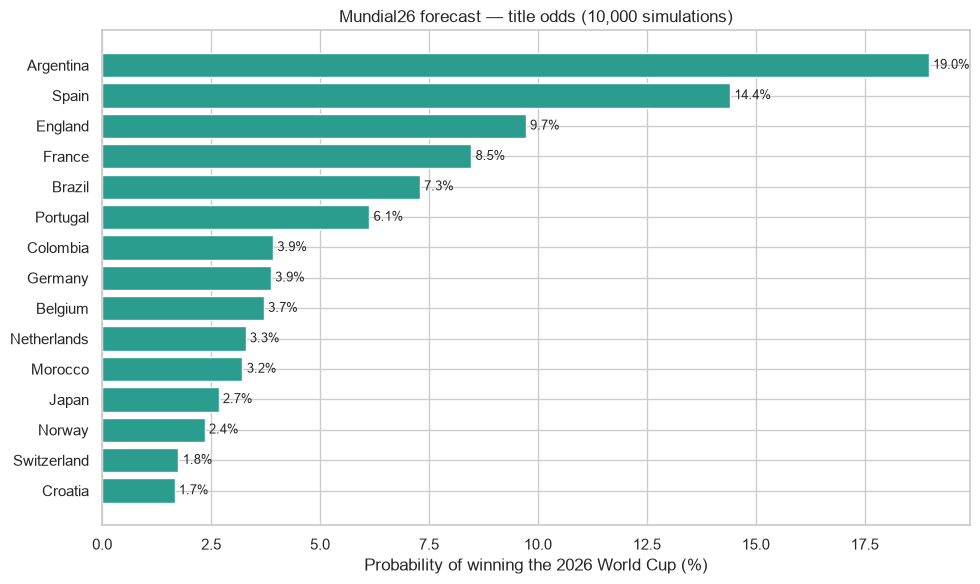

In [12]:
top = table.head(15).iloc[::-1]
plt.barh(top["Team"], top["Win %"], color="#2a9d8f")
plt.xlabel("Probability of winning the 2026 World Cup (%)")
plt.title(f"Mundial26 forecast — title odds ({N_SIMS:,} simulations)")
for i,(v,t) in enumerate(zip(top["Win %"], top["Team"])):
    plt.text(v+0.1, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()

## 10. Spotlight: Egypt 🇪🇬
A look at how the model sees Egypt's run (Group G, alongside Belgium, Iran and New Zealand).

In [13]:
egy = table[table["Team"]=="Egypt"].iloc[0]
print("Egypt — model forecast")
print(f"  Advance from group: {egy['Advance %']:.1f}%")
print(f"  Reach semi-final:   {egy['Semi %']:.1f}%")
print(f"  Reach final:        {egy['Final %']:.1f}%")
print(f"  Win the cup:        {egy['Win %']:.1f}%")

Egypt — model forecast
  Advance from group: 77.0%
  Reach semi-final:   3.0%
  Reach final:        0.8%
  Win the cup:        0.3%


## 11. Save the forecast
Stored for the Phase 6 dashboard, which will display these odds and track them live.

In [14]:
import os
os.makedirs("../models", exist_ok=True)
table.round(2).to_csv("../models/forecast.csv", index=False)
print("Saved ../models/forecast.csv")

Saved ../models/forecast.csv


---
### What's next (Phases 5 & 6)
- **Phase 5 — Backtesting & calibration:** prove the whole pipeline is sound by running it on
  the 2018 and 2022 World Cups (predict them with prior data, check log loss & calibration).
- **Phase 6 — Live Streamlit dashboard:** display these odds, the bracket, and a tracker that
  re-runs the forecast as new results come in — your shareable, recruiter-facing artifact.